In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
#Import libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

In [ ]:
# Set a random deed: makes the patient spliy and model training more reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
# Define the permaneny data paths
prepared_root = (
    "/content/drive/MyDrive/AI_Medical/COCA/coca_prepared"
)

images_dir = os.path.join(
    prepared_root,
    "images"
)

masks_dir = os.path.join(
    prepared_root,
    "masks"
)

index_path = os.path.join(
    prepared_root,
    "dataset_index.csv"
)

week3_output = os.path.join(
    prepared_root,
    "week3_results"
)

os.makedirs(
    week3_output,
    exist_ok=True
)

print("Images folder exists:", os.path.exists(images_dir))
print("Masks folder exists:", os.path.exists(masks_dir))
print("Dataset index exists:", os.path.exists(index_path))
print("Week 3 output:", week3_output)

Images folder exists: True
Masks folder exists: True
Dataset index exists: True
Week 3 output: /content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results


In [ ]:
#Count the saved files
image_files = [
    file
    for file in os.listdir(images_dir)
    if file.endswith(".npy")
]

mask_files = [
    file
    for file in os.listdir(masks_dir)
    if file.endswith(".npy")
]

print("Saved CT images:", len(image_files))
print("Saved masks:", len(mask_files))

Saved CT images: 3671
Saved masks: 3671


In [ ]:
# Load dataset_index.csv
dataset_index = pd.read_csv(index_path)

print("Image-mask pairs:", len(dataset_index))
print(
    "Unique patients:",
    dataset_index["Patient"].nunique()
)

dataset_index.head()

Image-mask pairs: 3671
Unique patients: 449


,Patient,ImageIndex,Filename,DICOMFile,InstanceNumber,ROI_z,DICOM_z,ZDifference,NumberOfROIs,MaskPixels,Height,Width
0,0,34,patient_0_slice_34.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,23,-183.25,-183.25,0.0,1,13,512,512
1,1,12,patient_1_slice_12.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,45,-214.75,-214.75,0.0,1,18,512,512
2,1,19,patient_1_slice_19.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,38,-193.75,-193.75,0.0,1,10,512,512
3,1,26,patient_1_slice_26.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,31,-172.75,-172.75,0.0,1,4,512,512
4,1,27,patient_1_slice_27.npy,/content/drive/MyDrive/AI_Medical/COCA/raw_dat...,30,-169.75,-169.75,0.0,2,71,512,512


In [ ]:
dataset_index["ImageExists"] = dataset_index["Filename"].apply(
    lambda filename: os.path.exists(
        os.path.join(images_dir, filename)
    )
)

dataset_index["MaskExists"] = dataset_index["Filename"].apply(
    lambda filename: os.path.exists(
        os.path.join(masks_dir, filename)
    )
)

print(
    "Missing images:",
    (~dataset_index["ImageExists"]).sum()
)

print(
    "Missing masks:",
    (~dataset_index["MaskExists"]).sum()
)

Missing images: 0
Missing masks: 0


In [ ]:
dataset_index = dataset_index.drop(
    columns=["ImageExists", "MaskExists"]
)

In [ ]:
# Split the patient
patient_ids = dataset_index["Patient"].unique()

train_patients, temporary_patients = train_test_split(
    patient_ids,
    test_size=0.30,
    random_state=SEED
)

val_patients, test_patients = train_test_split(
    temporary_patients,
    test_size=0.50,
    random_state=SEED
)

print("Training patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Test patients:", len(test_patients))
print(
    "Total patients:",
    len(train_patients)
    + len(val_patients)
    + len(test_patients)
)

Training patients: 314
Validation patients: 67
Test patients: 68
Total patients: 449


In [ ]:
# Create the three dataframes
train_df = dataset_index[
    dataset_index["Patient"].isin(train_patients)
].reset_index(drop=True)

val_df = dataset_index[
    dataset_index["Patient"].isin(val_patients)
].reset_index(drop=True)

test_df = dataset_index[
    dataset_index["Patient"].isin(test_patients)
].reset_index(drop=True)

print("Training pairs:", len(train_df))
print("Validation pairs:", len(val_df))
print("Test pairs:", len(test_df))

print(
    "Total pairs:",
    len(train_df) + len(val_df) + len(test_df)
)

Training pairs: 2588
Validation pairs: 555
Test pairs: 528
Total pairs: 3671


In [ ]:
# Check for patient leakage
train_patient_set = set(train_df["Patient"])
val_patient_set = set(val_df["Patient"])
test_patient_set = set(test_df["Patient"])

print(
    "Train–validation overlap:",
    len(train_patient_set & val_patient_set)
)

print(
    "Train–test overlap:",
    len(train_patient_set & test_patient_set)
)

print(
    "Validation–test overlap:",
    len(val_patient_set & test_patient_set)
)

Train–validation overlap: 0
Train–test overlap: 0
Validation–test overlap: 0


In [ ]:
# Save the patient splits
split_dir = os.path.join(
    prepared_root,
    "splits"
)

os.makedirs(
    split_dir,
    exist_ok=True
)

train_df.to_csv(
    os.path.join(split_dir, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(split_dir, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(split_dir, "test.csv"),
    index=False
)

print("Split files saved in:")
print(split_dir)

Split files saved in:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/splits


In [ ]:
# Create the Pytorch dataset
class COCACalciumDataset(Dataset):

    def __init__(
        self,
        dataframe,
        images_dir,
        masks_dir,
        image_size=256
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_size = image_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]
        filename = row["Filename"]

        image_path = os.path.join(
            self.images_dir,
            filename
        )

        mask_path = os.path.join(
            self.masks_dir,
            filename
        )

        image = np.load(
            image_path
        ).astype(np.float32)

        mask = np.load(
            mask_path
        ).astype(np.float32)

        # Clip the CT values to a useful HU range
        image = np.clip(
            image,
            -200,
            1000
        )

        # Normalize the image to 0–1
        image = (
            image - (-200)
        ) / (
            1000 - (-200)
        )

        # Ensure the mask remains binary
        mask = (
            mask > 0
        ).astype(np.float32)

        # Add the channel dimension:
        # (height, width) → (1, height, width)
        image = torch.from_numpy(
            image
        ).unsqueeze(0)

        mask = torch.from_numpy(
            mask
        ).unsqueeze(0)

        # Resize the image using bilinear interpolation
        image = F.interpolate(
            image.unsqueeze(0),
            size=(
                self.image_size,
                self.image_size
            ),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        # Resize the mask using nearest-neighbor interpolation
        # so mask values remain 0 or 1
        mask = F.interpolate(
            mask.unsqueeze(0),
            size=(
                self.image_size,
                self.image_size
            ),
            mode="nearest"
        ).squeeze(0)

        return {
            "image": image,
            "mask": mask,
            "filename": filename,
            "patient": row["Patient"]
        }

In [ ]:
# Create the datasets
IMAGE_SIZE = 256

train_dataset = COCACalciumDataset(
    dataframe=train_df,
    images_dir=images_dir,
    masks_dir=masks_dir,
    image_size=IMAGE_SIZE
)

val_dataset = COCACalciumDataset(
    dataframe=val_df,
    images_dir=images_dir,
    masks_dir=masks_dir,
    image_size=IMAGE_SIZE
)

test_dataset = COCACalciumDataset(
    dataframe=test_df,
    images_dir=images_dir,
    masks_dir=masks_dir,
    image_size=IMAGE_SIZE
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 2588
Validation samples: 555
Test samples: 528


In [ ]:
# Test one sample
sample = train_dataset[0]

print("Filename:", sample["filename"])
print("Patient:", sample["patient"])
print("Image shape:", sample["image"].shape)
print("Mask shape:", sample["mask"].shape)
print("Image minimum:", sample["image"].min().item())
print("Image maximum:", sample["image"].max().item())
print("Mask values:", torch.unique(sample["mask"]))
print("Positive pixels:", sample["mask"].sum().item())

Filename: patient_1_slice_12.npy
Patient: 1
Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image minimum: 0.0
Image maximum: 0.9054166674613953
Mask values: tensor([0., 1.])
Positive pixels: 5.0


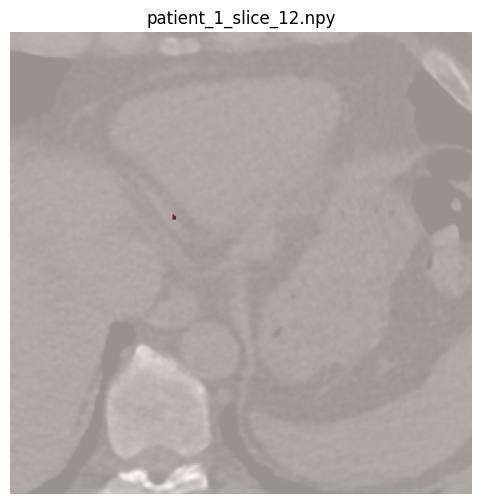

In [ ]:
# Display the sample
image = sample["image"].squeeze().numpy()
mask = sample["mask"].squeeze().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.imshow(mask, cmap="Reds", alpha=0.6)
plt.title(sample["filename"])
plt.axis("off")
plt.show()

In [ ]:
# Create the data loaders
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 647
Validation batches: 139
Test batches: 132


In [ ]:
# Check one batch
batch = next(
    iter(train_loader)
)

print("Batch image shape:", batch["image"].shape)
print("Batch mask shape:", batch["mask"].shape)
print("Number of filenames:", len(batch["filename"]))

Batch image shape: torch.Size([4, 1, 256, 256])
Batch mask shape: torch.Size([4, 1, 256, 256])
Number of filenames: 4


In [ ]:
# Define the U-Net building block
class DoubleConv(nn.Module):

    def __init__(
        self,
        input_channels,
        output_channels
    ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(
                input_channels,
                output_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                output_channels
            ),
            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                output_channels,
                output_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(
                output_channels
            ),
            nn.ReLU(
                inplace=True
            )
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
# Define small UNet
class SmallUNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder1 = DoubleConv(
            1,
            32
        )

        self.encoder2 = DoubleConv(
            32,
            64
        )

        self.encoder3 = DoubleConv(
            64,
            128
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2
        )

        # Bottleneck
        self.bottleneck = DoubleConv(
            128,
            256
        )

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.decoder3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.decoder2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose2d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.decoder1 = DoubleConv(
            64,
            32
        )

        self.output_layer = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        encoder1 = self.encoder1(x)

        encoder2 = self.encoder2(
            self.pool(encoder1)
        )

        encoder3 = self.encoder3(
            self.pool(encoder2)
        )

        bottleneck = self.bottleneck(
            self.pool(encoder3)
        )

        decoder3 = self.up3(
            bottleneck
        )

        decoder3 = torch.cat(
            [decoder3, encoder3],
            dim=1
        )

        decoder3 = self.decoder3(
            decoder3
        )

        decoder2 = self.up2(
            decoder3
        )

        decoder2 = torch.cat(
            [decoder2, encoder2],
            dim=1
        )

        decoder2 = self.decoder2(
            decoder2
        )

        decoder1 = self.up1(
            decoder2
        )

        decoder1 = torch.cat(
            [decoder1, encoder1],
            dim=1
        )

        decoder1 = self.decoder1(
            decoder1
        )

        return self.output_layer(
            decoder1
        )

In [ ]:
#Create and test model
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = SmallUNet().to(device)

print("Device:", device)

test_input = torch.randn(
    2,
    1,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)

with torch.no_grad():
    test_output = model(
        test_input
    )

print("Test input shape:", test_input.shape)
print("Model output shape:", test_output.shape)

Device: cuda
Test input shape: torch.Size([2, 1, 256, 256])
Model output shape: torch.Size([2, 1, 256, 256])


In [ ]:
#Define Dice coefficient
def dice_coefficient(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-6
):
    probabilities = torch.sigmoid(
        predictions
    )

    binary_predictions = (
        probabilities > threshold
    ).float()

    binary_predictions = binary_predictions.view(
        binary_predictions.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        binary_predictions * targets
    ).sum(dim=1)

    dice = (
        2 * intersection + smooth
    ) / (
        binary_predictions.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return dice.mean()

In [ ]:
# BCE + Dice loss
def soft_dice_loss(
    predictions,
    targets,
    smooth=1e-6
):
    probabilities = torch.sigmoid(
        predictions
    )

    probabilities = probabilities.view(
        probabilities.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        probabilities * targets
    ).sum(dim=1)

    dice = (
        2 * intersection + smooth
    ) / (
        probabilities.sum(dim=1)
        + targets.sum(dim=1)
        + smooth
    )

    return 1 - dice.mean()


bce_loss = nn.BCEWithLogitsLoss()


def combined_loss(
    predictions,
    targets
):
    bce = bce_loss(
        predictions,
        targets
    )

    dice = soft_dice_loss(
        predictions,
        targets
    )

    return bce + dice

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
# Define one training epoch
def train_one_epoch(
    model,
    data_loader,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_dice = 0.0

    for batch in data_loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        predictions = model(
            images
        )

        loss = combined_loss(
            predictions,
            masks
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        with torch.no_grad():
            total_dice += dice_coefficient(
                predictions,
                masks
            ).item()

    average_loss = (
        total_loss / len(data_loader)
    )

    average_dice = (
        total_dice / len(data_loader)
    )

    return average_loss, average_dice

In [ ]:
#Define validation
def validate_one_epoch(
    model,
    data_loader,
    device
):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0

    with torch.no_grad():

        for batch in data_loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            masks = batch["mask"].to(
                device,
                non_blocking=True
            )

            predictions = model(
                images
            )

            loss = combined_loss(
                predictions,
                masks
            )

            total_loss += loss.item()

            total_dice += dice_coefficient(
                predictions,
                masks
            ).item()

    average_loss = (
        total_loss / len(data_loader)
    )

    average_dice = (
        total_dice / len(data_loader)
    )

    return average_loss, average_dice

In [31]:
# Train the model
NUM_EPOCHS = 5

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": []
}

best_val_loss = float("inf")

best_model_path = os.path.join(
    week3_output,
    "best_unet_model.pth"
)

for epoch in range(NUM_EPOCHS):

    train_loss, train_dice = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss, val_dice = validate_one_epoch(
        model,
        val_loader,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_dice"].append(
        train_dice
    )

    history["val_dice"].append(
        val_dice
    )

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Train Dice: {train_dice:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("Best model saved.")

Epoch 1/5 | Train loss: 1.4121 | Val loss: 1.2905 | Train Dice: 0.0028 | Val Dice: 0.0108
Best model saved.
Epoch 2/5 | Train loss: 1.2135 | Val loss: 1.1386 | Train Dice: 0.0806 | Val Dice: 0.3625
Best model saved.
Epoch 3/5 | Train loss: 1.1003 | Val loss: 1.0651 | Train Dice: 0.4923 | Val Dice: 0.4381
Best model saved.
Epoch 4/5 | Train loss: 1.0422 | Val loss: 1.0221 | Train Dice: 0.5277 | Val Dice: 0.5428
Best model saved.
Epoch 5/5 | Train loss: 1.0027 | Val loss: 0.9797 | Train Dice: 0.5596 | Val Dice: 0.6120
Best model saved.


In [32]:
# Load the best saved model

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

best_model_path = os.path.join(
    week3_output,
    "best_unet_model.pth"
)

model = SmallUNet().to(device)

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("Best model loaded from:")
print(best_model_path)
print("Model file exists:", os.path.exists(best_model_path))

Best model loaded from:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/best_unet_model.pth
Model file exists: True


In [33]:
# Evaluate the best model on the test set

def calculate_batch_metrics(
    predictions,
    targets,
    threshold=0.5,
    smooth=1e-6
):
    probabilities = torch.sigmoid(predictions)

    predicted_masks = (
        probabilities > threshold
    ).float()

    predicted_masks = predicted_masks.view(
        predicted_masks.size(0),
        -1
    )

    targets = targets.view(
        targets.size(0),
        -1
    )

    intersection = (
        predicted_masks * targets
    ).sum(dim=1)

    predicted_sum = predicted_masks.sum(dim=1)
    target_sum = targets.sum(dim=1)

    dice = (
        2 * intersection + smooth
    ) / (
        predicted_sum + target_sum + smooth
    )

    union = (
        predicted_sum
        + target_sum
        - intersection
    )

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return dice, iou

In [34]:
# Run test-set evaluation

test_records = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        images = batch["image"].to(device)
        masks = batch["mask"].to(device)

        outputs = model(images)

        dice_scores, iou_scores = calculate_batch_metrics(
            outputs,
            masks
        )

        filenames = batch["filename"]
        patients = batch["patient"]

        for i in range(len(filenames)):

            test_records.append({
                "Patient": int(patients[i]),
                "Filename": filenames[i],
                "Dice": float(dice_scores[i].cpu()),
                "IoU": float(iou_scores[i].cpu())
            })

In [35]:
# Save test metrics to Google Drive

test_metrics_df = pd.DataFrame(test_records)

test_metrics_path = os.path.join(
    week3_output,
    "test_metrics.csv"
)

test_metrics_df.to_csv(
    test_metrics_path,
    index=False
)

print("Mean test Dice:", test_metrics_df["Dice"].mean())
print("Mean test IoU:", test_metrics_df["IoU"].mean())

print("Saved to:")
print(test_metrics_path)
print("File exists:", os.path.exists(test_metrics_path))

Mean test Dice: 0.6318922647065641
Mean test IoU: 0.5048565465281876
Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/test_metrics.csv
File exists: True


In [37]:
# Create and save an evaluation summary

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Test image-mask pairs",
        "Mean Dice",
        "Median Dice",
        "Mean IoU",
        "Median IoU"
    ],
    "Value": [
        len(test_metrics_df),
        test_metrics_df["Dice"].mean(),
        test_metrics_df["Dice"].median(),
        test_metrics_df["IoU"].mean(),
        test_metrics_df["IoU"].median()
    ]
})

evaluation_summary_path = os.path.join(
    week3_output,
    "evaluation_summary.csv"
)

evaluation_summary.to_csv(
    evaluation_summary_path,
    index=False
)

evaluation_summary

,Metric,Value
0,Test image-mask pairs,528.000000
1,Mean Dice,0.631892
2,Median Dice,0.693980
3,Mean IoU,0.504857
4,Median IoU,0.531373


In [38]:
print("Saved to:")
print(evaluation_summary_path)
print("File exists:", os.path.exists(evaluation_summary_path))

Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/evaluation_summary.csv
File exists: True


## Prediction Visualization

In [39]:
# Get one batch from the test set

test_batch = next(iter(test_loader))

test_images = test_batch["image"].to(device)
test_masks = test_batch["mask"].to(device)
test_filenames = test_batch["filename"]

print("Image batch shape:", test_images.shape)
print("Mask batch shape:", test_masks.shape)
print("First filename:", test_filenames[0])

Image batch shape: torch.Size([4, 1, 256, 256])
Mask batch shape: torch.Size([4, 1, 256, 256])
First filename: patient_100_slice_13.npy


In [40]:
# Generate predictions using the best trained model

model.eval()

with torch.no_grad():

    test_outputs = model(test_images)

    test_probabilities = torch.sigmoid(
        test_outputs
    )

    predicted_masks = (
        test_probabilities > 0.5
    ).float()

print("Prediction shape:", predicted_masks.shape)
print(
    "Predicted mask values:",
    torch.unique(predicted_masks)
)

Prediction shape: torch.Size([4, 1, 256, 256])
Predicted mask values: tensor([0., 1.], device='cuda:0')


In [41]:
# Generate predictions using the best trained model

model.eval()

with torch.no_grad():

    test_outputs = model(test_images)

    test_probabilities = torch.sigmoid(
        test_outputs
    )

    predicted_masks = (
        test_probabilities > 0.5
    ).float()

print("Prediction shape:", predicted_masks.shape)
print(
    "Predicted mask values:",
    torch.unique(predicted_masks)
)

Prediction shape: torch.Size([4, 1, 256, 256])
Predicted mask values: tensor([0., 1.], device='cuda:0')


In [42]:
# Calculate Dice score for every image in the batch

def dice_per_image(
    predicted_masks,
    true_masks,
    smooth=1e-6
):
    predicted_flat = predicted_masks.view(
        predicted_masks.size(0),
        -1
    )

    true_flat = true_masks.view(
        true_masks.size(0),
        -1
    )

    intersection = (
        predicted_flat * true_flat
    ).sum(dim=1)

    dice_scores = (
        2 * intersection + smooth
    ) / (
        predicted_flat.sum(dim=1)
        + true_flat.sum(dim=1)
        + smooth
    )

    return dice_scores


batch_dice_scores = dice_per_image(
    predicted_masks,
    test_masks
)

for i, score in enumerate(batch_dice_scores):
    print(
        test_filenames[i],
        "| Dice:",
        round(score.item(), 4)
    )

patient_100_slice_13.npy | Dice: 0.7879
patient_100_slice_14.npy | Dice: 0.8966
patient_100_slice_15.npy | Dice: 0.7778
patient_100_slice_16.npy | Dice: 0.4


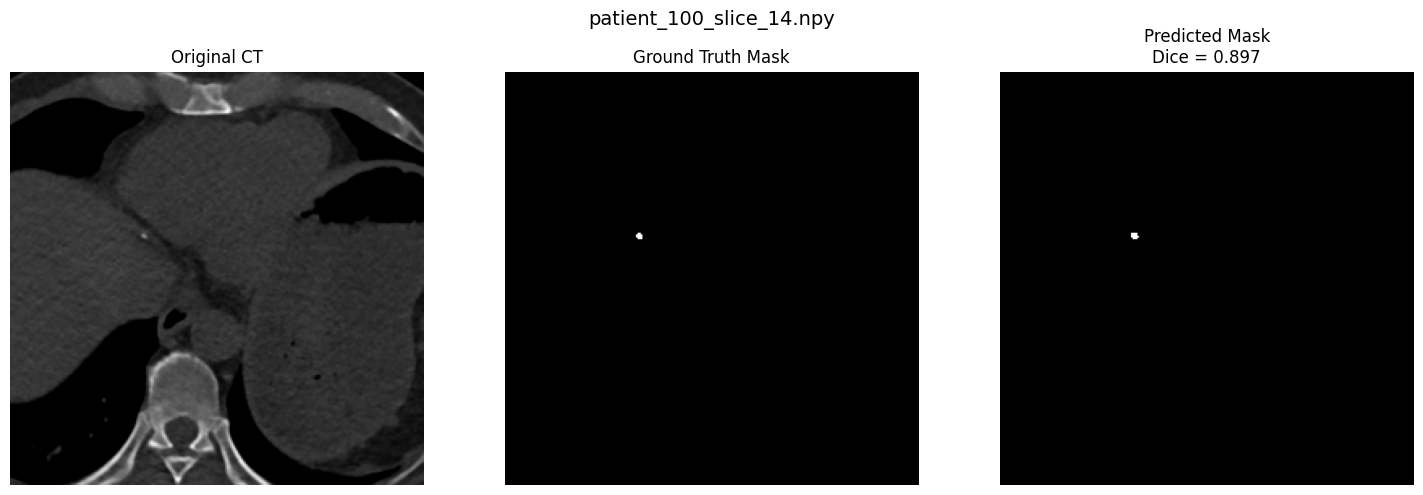

In [46]:
# Visualize one test prediction

sample_index = 1

image_to_show = (
    test_images[sample_index]
    .detach()
    .cpu()
    .squeeze()
    .numpy()
)

true_mask_to_show = (
    test_masks[sample_index]
    .detach()
    .cpu()
    .squeeze()
    .numpy()
)

pred_mask_to_show = (
    predicted_masks[sample_index]
    .detach()
    .cpu()
    .squeeze()
    .numpy()
)

sample_dice = batch_dice_scores[
    sample_index
].item()

sample_filename = test_filenames[
    sample_index
]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(
    image_to_show,
    cmap="gray"
)
plt.title("Original CT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    true_mask_to_show,
    cmap="gray"
)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    pred_mask_to_show,
    cmap="gray"
)
plt.title(
    f"Predicted Mask\nDice = {sample_dice:.3f}"
)
plt.axis("off")

plt.suptitle(
    sample_filename,
    fontsize=14
)

plt.tight_layout()
plt.show()

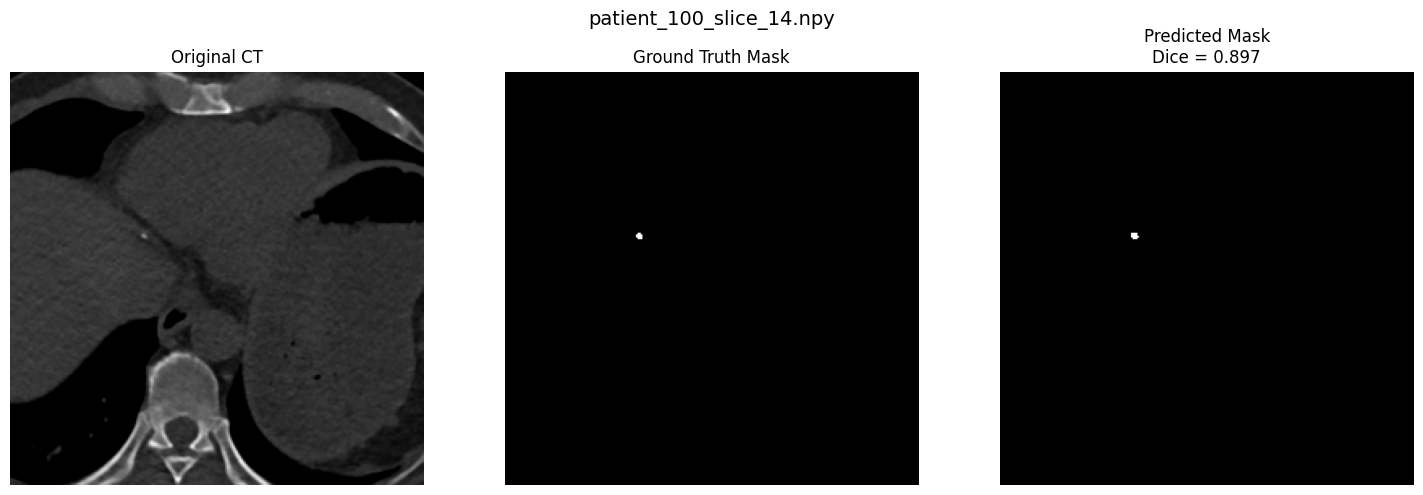

Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/prediction_example.png
File exists: True


In [47]:
# Save prediction visualization to Google Drive

prediction_figure_path = os.path.join(
    week3_output,
    "prediction_example.png"
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(
    image_to_show,
    cmap="gray"
)
plt.title("Original CT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    true_mask_to_show,
    cmap="gray"
)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(
    pred_mask_to_show,
    cmap="gray"
)
plt.title(
    f"Predicted Mask\nDice = {sample_dice:.3f}"
)
plt.axis("off")

plt.suptitle(
    sample_filename,
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    prediction_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(prediction_figure_path)
print(
    "File exists:",
    os.path.exists(prediction_figure_path)
)

In [48]:
train_losses = []
val_losses = []
train_dices = []
val_dices = []

In [49]:
train_losses.append(train_loss)
val_losses.append(val_loss)

train_dices.append(train_dice)
val_dices.append(val_dice)

In [51]:
print(train_losses)
print(val_losses)

[1.002682706764345]
[0.9796563777134573]


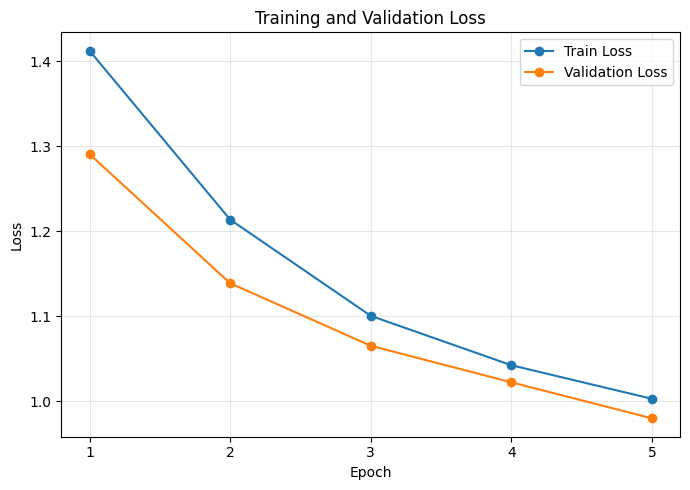

Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/loss_curve.png
File exists: True


In [52]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Rebuild the complete 5-epoch training history
train_losses = [
    1.4121,
    1.2135,
    1.1003,
    1.0422,
    1.0027
]

val_losses = [
    1.2905,
    1.1386,
    1.0651,
    1.0221,
    0.9797
]

epochs = range(1, 6)

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_curve_path = os.path.join(
    week3_output,
    "loss_curve.png"
)

plt.savefig(
    loss_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(loss_curve_path)
print("File exists:", os.path.exists(loss_curve_path))

In [53]:
training_history_df = pd.DataFrame({
    "Epoch": list(epochs),
    "TrainLoss": train_losses,
    "ValidationLoss": val_losses
})

history_path = os.path.join(
    week3_output,
    "training_history.csv"
)

training_history_df.to_csv(
    history_path,
    index=False
)

print(training_history_df)

print("\nSaved to:")
print(history_path)
print("File exists:", os.path.exists(history_path))

   Epoch  TrainLoss  ValidationLoss
0      1     1.4121          1.2905
1      2     1.2135          1.1386
2      3     1.1003          1.0651
3      4     1.0422          1.0221
4      5     1.0027          0.9797

Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/training_history.csv
File exists: True


In [55]:
all_dice_scores = test_metrics_df["Dice"].tolist()

print("Number of Dice scores:", len(all_dice_scores))
print("First 5 Dice scores:", all_dice_scores[:5])

Number of Dice scores: 528
First 5 Dice scores: [0.7878788709640503, 0.8965517282485962, 0.7777778506278992, 0.40000012516975403, 1.0]


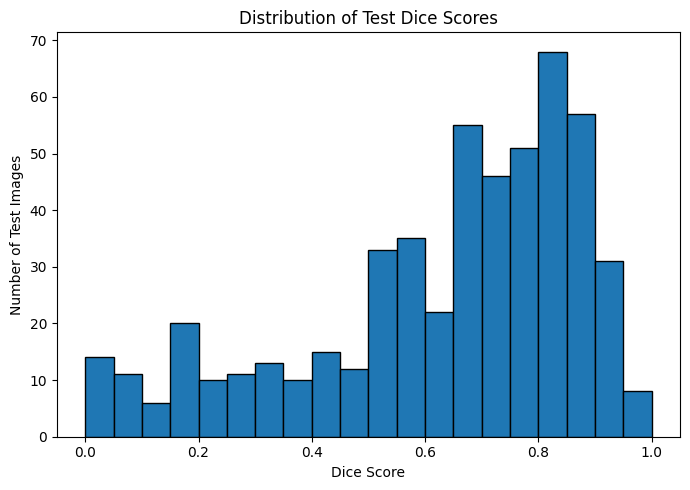

Saved to:
/content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/dice_distribution.png
File exists: True


In [56]:
import os
import matplotlib.pyplot as plt

dice_distribution_path = os.path.join(
    week3_output,
    "dice_distribution.png"
)

plt.figure(figsize=(7, 5))

plt.hist(
    all_dice_scores,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Dice Score")
plt.ylabel("Number of Test Images")
plt.title("Distribution of Test Dice Scores")

plt.tight_layout()

plt.savefig(
    dice_distribution_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(dice_distribution_path)
print(
    "File exists:",
    os.path.exists(dice_distribution_path)
)

In [57]:
import os
import pandas as pd

train_losses = [
    1.4121,
    1.2135,
    1.1003,
    1.0422,
    1.0027
]

val_losses = [
    1.2905,
    1.1386,
    1.0651,
    1.0221,
    0.9797
]

train_dices = [
    0.0028,
    0.0806,
    0.4923,
    0.5277,
    0.5596
]

val_dices = [
    0.0108,
    0.3625,
    0.4381,
    0.5428,
    0.6120
]

training_history_df = pd.DataFrame({
    "Epoch": [1, 2, 3, 4, 5],
    "TrainLoss": train_losses,
    "ValidationLoss": val_losses,
    "TrainDice": train_dices,
    "ValidationDice": val_dices
})

training_history_path = os.path.join(
    week3_output,
    "training_history.csv"
)

training_history_df.to_csv(
    training_history_path,
    index=False
)

print(training_history_df)
print("\nSaved to:", training_history_path)
print("File exists:", os.path.exists(training_history_path))

   Epoch  TrainLoss  ValidationLoss  TrainDice  ValidationDice
0      1     1.4121          1.2905     0.0028          0.0108
1      2     1.2135          1.1386     0.0806          0.3625
2      3     1.1003          1.0651     0.4923          0.4381
3      4     1.0422          1.0221     0.5277          0.5428
4      5     1.0027          0.9797     0.5596          0.6120

Saved to: /content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/training_history.csv
File exists: True


In [58]:
test_metrics_path = os.path.join(
    week3_output,
    "test_metrics.csv"
)

test_metrics_df.to_csv(
    test_metrics_path,
    index=False
)

print("Saved to:", test_metrics_path)
print("File exists:", os.path.exists(test_metrics_path))

Saved to: /content/drive/MyDrive/AI_Medical/COCA/coca_prepared/week3_results/test_metrics.csv
File exists: True
